In [1]:
# ============================================================
# 04_experiment4 - TF-IDF Vocabulary Size Comparison
# ============================================================
# Purpose: Train Random Forest on email text using different
#          TF-IDF max_features values to determine how
#          vocabulary size impacts phishing detection accuracy.
#          Tests: 500, 1000, 2500, 5000, 10000 features.
# ============================================================

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score)

In [3]:
df_email1 = pd.read_csv('../data/processed/email1_clean.csv')
df_email2 = pd.read_csv('../data/processed/email2_clean.csv')
df_email2 = df_email2.rename(columns={'text': 'text_combined'})

df_emails = pd.concat([df_email1, df_email2], ignore_index=True)
df_emails = df_emails.dropna(subset=['text_combined'])
df_emails = df_emails.drop_duplicates()

X_text = df_emails['text_combined']
y      = df_emails['label']

X_temp, X_test_e, y_temp, y_test_e = train_test_split(
    X_text, y, test_size=0.15,
    random_state=489, stratify=y
)
X_train_e, X_val_e, y_train_e, y_val_e = train_test_split(
    X_temp, y_temp, test_size=0.1765,
    random_state=489, stratify=y_temp
)

print(f"Train: {len(X_train_e)} | Val: {len(X_val_e)} | Test: {len(X_test_e)}")

Train: 69722 | Val: 14944 | Test: 14942


In [4]:
vocab_sizes = [500, 1000, 2500, 5000, 10000]
exp4_results = []

for max_feat in vocab_sizes:
    print(f"Testing max_features={max_feat}...")

    tfidf = TfidfVectorizer(
        max_features=max_feat, stop_words='english'
    )
    X_train_tfidf = tfidf.fit_transform(X_train_e)
    X_val_tfidf   = tfidf.transform(X_val_e)

    model = RandomForestClassifier(
        n_estimators=100, random_state=489
    )
    model.fit(X_train_tfidf, y_train_e)

    start = time.time()
    y_pred = model.predict(X_val_tfidf)
    inference_ms = (time.time() - start) / len(y_val_e) * 1000

    metrics = {
        'max_features': max_feat,
        'accuracy':     accuracy_score(y_val_e, y_pred),
        'precision':    precision_score(y_val_e, y_pred, zero_division=0),
        'recall':       recall_score(y_val_e, y_pred, zero_division=0),
        'f1':           f1_score(y_val_e, y_pred, zero_division=0),
        'auc':          roc_auc_score(y_val_e, y_pred),
        'inference_ms': round(inference_ms, 4)
    }
    exp4_results.append(metrics)

    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  Inference: {metrics['inference_ms']:.4f}ms\n")

exp4_df = pd.DataFrame(exp4_results)
exp4_df.to_csv('../results/experiment4_results.csv', index=False)

print("Experiment 4 complete")
print(exp4_df[['max_features','accuracy','precision','recall','f1']])

Testing max_features=500...
  Accuracy:  0.9774
  F1:        0.9772
  Inference: 0.0143ms

Testing max_features=1000...
  Accuracy:  0.9811
  F1:        0.9810
  Inference: 0.0156ms

Testing max_features=2500...
  Accuracy:  0.9860
  F1:        0.9859
  Inference: 0.0184ms

Testing max_features=5000...
  Accuracy:  0.9875
  F1:        0.9874
  Inference: 0.0213ms

Testing max_features=10000...
  Accuracy:  0.9886
  F1:        0.9885
  Inference: 0.0228ms

Experiment 4 complete
   max_features  accuracy  precision    recall        f1
0           500  0.977382   0.975912  0.978545  0.977227
1          1000  0.981130   0.979809  0.982189  0.980997
2          2500  0.986014   0.986753  0.985022  0.985887
3          5000  0.987487   0.988240  0.986507  0.987373
4         10000  0.988557   0.988661  0.988261  0.988461


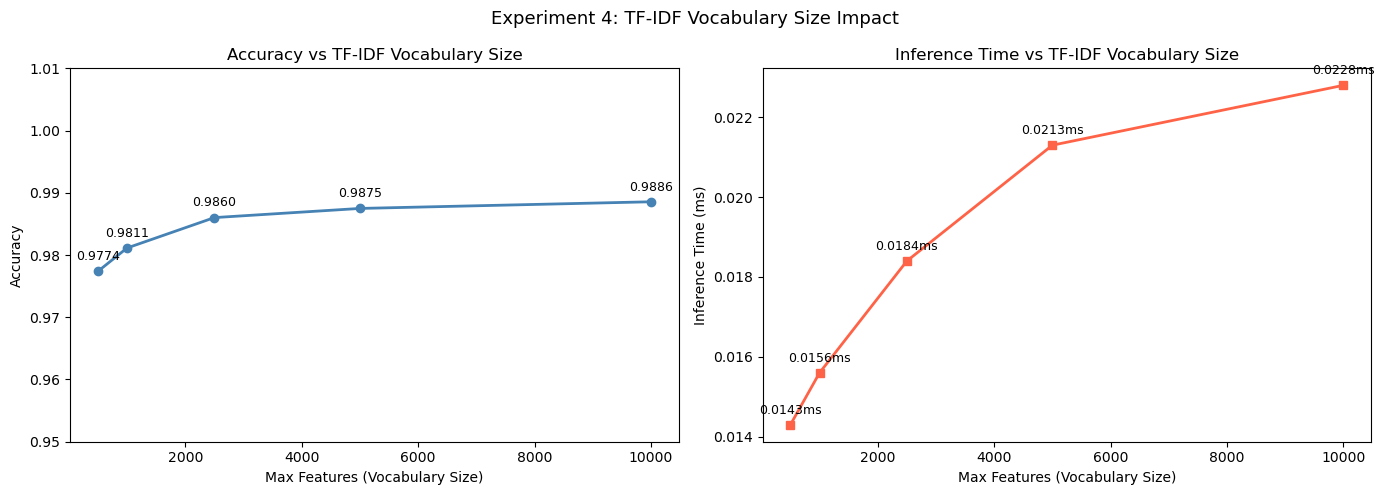

Chart saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy line
axes[0].plot(exp4_df['max_features'], exp4_df['accuracy'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Accuracy vs TF-IDF Vocabulary Size')
axes[0].set_xlabel('Max Features (Vocabulary Size)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.95, 1.01)
for x, y_val in zip(exp4_df['max_features'], exp4_df['accuracy']):
    axes[0].annotate(f'{y_val:.4f}', (x, y_val),
                     textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

# Inference time line
axes[1].plot(exp4_df['max_features'], exp4_df['inference_ms'],
             marker='s', color='tomato', linewidth=2)
axes[1].set_title('Inference Time vs TF-IDF Vocabulary Size')
axes[1].set_xlabel('Max Features (Vocabulary Size)')
axes[1].set_ylabel('Inference Time (ms)')
for x, y_val in zip(exp4_df['max_features'], exp4_df['inference_ms']):
    axes[1].annotate(f'{y_val:.4f}ms', (x, y_val),
                     textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('Experiment 4: TF-IDF Vocabulary Size Impact', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/experiment4_vocab_size.png', dpi=150)
plt.show()
print("Chart saved")

In [6]:
print("=== EXPERIMENT 4 FULL RESULTS ===")
print(exp4_df[['max_features','accuracy','precision',
               'recall','f1','auc','inference_ms']].to_string())

# Find optimal vocabulary size
best_idx = exp4_df['accuracy'].idxmax()
best_size = exp4_df.loc[best_idx, 'max_features']
best_acc  = exp4_df.loc[best_idx, 'accuracy']
print(f"\nOptimal vocabulary size: {best_size} features")
print(f"Best accuracy: {best_acc:.4f}")

=== EXPERIMENT 4 FULL RESULTS ===
   max_features  accuracy  precision    recall        f1       auc  inference_ms
0           500  0.977382   0.975912  0.978545  0.977227  0.977392        0.0143
1          1000  0.981130   0.979809  0.982189  0.980997  0.981138        0.0156
2          2500  0.986014   0.986753  0.985022  0.985887  0.986006        0.0184
3          5000  0.987487   0.988240  0.986507  0.987373  0.987479        0.0213
4         10000  0.988557   0.988661  0.988261  0.988461  0.988555        0.0228

Optimal vocabulary size: 10000 features
Best accuracy: 0.9886
